# Training with Cleaned Dataset and EDL Type 2
A notebook for training an EfficientNet B3 model with Evidential Deep Learning (EDL Type 2) on a 5-class diabetic retinopathy dataset.
Dataset: `cleaned_dataset` with `train`, `val`, and `test` splits and 0-4 class folders.

## Execution Flow (Single Best Path Only)
1. Run Cells 1-6
2. Run Cell 7 (k-fold training)
3. Run Cell 8 (ensemble evaluation)
4. Run Cell 9 (final checkpoint download)

This notebook now uses only the best-performance path.

## 1. Import Core Libraries

In [1]:
!pip install torch torchvision timm efficientnet-pytorch scikit-learn pandas matplotlib seaborn opencv-python

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

  Preparing metadata (setup.py) ... done
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=9512314709e76d46a69c5ec6c7499310d47643d0587a5a9bd1a206fd5f76f9c6
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
Successfully built efficientnet-pytorch


## 2. Define Hyperparameters and Device Configuration

In [2]:
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
NUM_EPOCHS = 60
NUM_CLASSES = 5
PATIENCE = 15

# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download('dondirecto/dr-training')
print(f"Dataset path: {dataset_path}")

# Set base paths to point to the local workspace folder
BASE_DIR = os.path.join(dataset_path, 'cleaned_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

Using device: cuda
Using Colab cache for faster access to the 'dr-training' dataset.
Dataset path: /kaggle/input/dr-training


## 3. Configure Data Transforms and Loaders

In [3]:
from torch.utils.data import WeightedRandomSampler

import cv2
from PIL import Image

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = self.clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

# Sampler weights for balancing minibatches
sampler_class_weights = 1.0 / torch.tensor(np.clip(class_counts, 1, None), dtype=torch.float)

# Explicitly protect class-2/3 collapse by increasing sampling pressure
CLASS2_BOOST = 2.0
CLASS3_BOOST = 1.4
sampler_class_weights[2] = sampler_class_weights[2] * CLASS2_BOOST
sampler_class_weights[3] = sampler_class_weights[3] * CLASS3_BOOST
sample_weights = sampler_class_weights[train_targets]

# Loss weights for stronger minority-class learning (mean-normalized for stable scale)
class_weights_for_loss = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * np.clip(class_counts, 1, None)),
    dtype=torch.float,
    device=device
)
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()
class_weights_for_loss[2] = class_weights_for_loss[2] * 1.4
class_weights_for_loss[3] = class_weights_for_loss[3] * 1.2
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Original Class Counts in Train: {class_counts}")
print(f"Sampler Class Weights: {sampler_class_weights}")
print(f"Loss Class Weights (normalized): {class_weights_for_loss}")
print(f"Total Dataset Sizes: {dataset_sizes}")

Classes: ['0', '1', '2', '3', '4']
Original Class Counts in Train: [6777 3712 2568 1321 1545]
Sampler Class Weights: tensor([0.0001, 0.0003, 0.0008, 0.0011, 0.0006])
Loss Class Weights (normalized): tensor([0.2930, 0.5350, 1.0826, 1.8040, 1.2854], device='cuda:0')
Total Dataset Sizes: {'train': 15923, 'val': 2090, 'test': 2426}


## 4. Define Evidential Deep Learning (Type 2) Loss

In [4]:
# Evidential Deep Learning (EDL) Loss Functions

def relu_evidence(y):
    return torch.nn.functional.relu(y)

def exp_evidence(y):
    return torch.exp(torch.clamp(y, -10, 10))

def softplus_evidence(y):
    return torch.nn.functional.softplus(y)

def kl_divergence(alpha, num_classes, device):
    beta = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    S_alpha = torch.sum(alpha, dim=1, keepdim=True)
    S_beta = torch.sum(beta, dim=1, keepdim=True)
    lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
    lnB_uni = torch.sum(torch.lgamma(beta), dim=1, keepdim=True) - torch.lgamma(S_beta)
    dg0 = torch.digamma(S_alpha)
    dg1 = torch.digamma(alpha)
    kl = torch.sum((alpha - beta) * (dg1 - dg0), dim=1, keepdim=True) + lnB + lnB_uni
    return kl

def focal_cross_entropy(logits, target, class_weights=None, label_smoothing=0.03, gamma=2.5):
    ce = F.cross_entropy(
        logits,
        target,
        weight=class_weights,
        label_smoothing=label_smoothing,
        reduction='none'
    )
    pt = torch.exp(-ce)
    focal = ((1 - pt) ** gamma) * ce
    return focal.mean()

def edl_type2_loss(
    output,
    target,
    epoch_num,
    num_classes,
    annealing_step,
    device,
    class_weights=None,
    epsilon=0.03,
    ce_weight=0.75,
    kl_scale=0.012,
    focal_gamma=2.5
 ):
    """
    Hybrid loss = EDL + class-weighted focal CE.
    Tuned defaults prioritize minority-class separation while preserving uncertainty modeling.
    """
    evidence = softplus_evidence(output)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)

    target_one_hot = torch.eye(num_classes, device=device)[target]
    target_smoothed = target_one_hot * (1.0 - epsilon) + (epsilon / num_classes)

    # EDL data-fit term
    err = torch.sum(target_smoothed * (torch.log(S + 1e-8) - torch.log(alpha + 1e-8)), dim=1, keepdim=True)

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32, device=device),
    )

    alpha_tilde = target_smoothed + (1 - target_smoothed) * alpha
    kl = kl_divergence(alpha_tilde, num_classes, device)
    edl_loss = torch.mean(err + (annealing_coef * kl * kl_scale))

    # Class-weighted focal CE drives separation for hard/minority classes
    focal_ce_loss = focal_cross_entropy(
        output,
        target,
        class_weights=class_weights,
        label_smoothing=epsilon,
        gamma=focal_gamma,
    )

    return (1.0 - ce_weight) * edl_loss + ce_weight * focal_ce_loss

## 5. Initialize EfficientNet B3 Model

In [5]:
class EfficientNetB3EDL(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetB3EDL, self).__init__()
        if pretrained:
            self.base_model = EfficientNet.from_pretrained('efficientnet-b3')
        else:
            self.base_model = EfficientNet.from_name('efficientnet-b3')

        in_features = self.base_model._fc.in_features

        # Stronger head improves class separation for adjacent DR grades.
        self.base_model._fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.35),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 398MB/s]


Loaded pretrained weights for efficientnet-b3


## 6. Implement Training and Validation Steps

In [6]:
# Strong single-run baseline (kept for quick checks before full k-fold)
optimizer = optim.AdamW(
    [
        {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
        {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
    ],
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_acc = 0.0
    best_f1 = 0.0
    epochs_no_improve = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    print("Freezing base model for initial warm-up...")
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            print("Unfreezing all layers for deep fine-tuning...")
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4  # head
            optimizer.param_groups[1]['lr'] = 5e-5  # backbone

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            if phase not in dataloaders:
                print(f"{phase} dataloader not found. Skipping.")
                continue

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=class_weights_for_loss,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_f1'].append(epoch_f1)

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}")

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_edl2_efficientnet.pth')
                    print(f" -> Best model saved! (Macro-F1: {best_f1:.4f})")
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping triggered after {epochs_no_improve} epochs without improvement')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Macro-F1: {best_f1:.4f} | Best val Acc: {best_acc:.4f} | Best val Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 7. K-Fold Cross-Validation (Stratified) and Fold Checkpoints
This section trains multiple folds on the training split and saves one best checkpoint per fold (`best_fold_1.pth`, ..., `best_fold_k.pth`).

Why this helps:
- Reduces dependency on one lucky/unlucky split
- Improves robustness for minority grades
- Produces diverse checkpoints for ensembling

In [7]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset


def build_optimizer_and_scheduler(model, total_epochs):
    optimizer = optim.AdamW(
        [
            {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
            {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
        ],
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)
    return optimizer, scheduler


def make_fold_weights(train_targets_fold, num_classes, device):
    class_counts_fold = np.bincount(train_targets_fold, minlength=num_classes)

    sampler_class_weights_fold = 1.0 / torch.tensor(np.clip(class_counts_fold, 1, None), dtype=torch.float)
    sampler_class_weights_fold[2] = sampler_class_weights_fold[2] * 2.0
    sampler_class_weights_fold[3] = sampler_class_weights_fold[3] * 1.4
    sample_weights_fold = sampler_class_weights_fold[train_targets_fold]

    loss_weights_fold = torch.tensor(
        class_counts_fold.sum() / (num_classes * np.clip(class_counts_fold, 1, None)),
        dtype=torch.float,
        device=device,
    )
    loss_weights_fold = loss_weights_fold / loss_weights_fold.mean()
    loss_weights_fold[2] = loss_weights_fold[2] * 1.4
    loss_weights_fold[3] = loss_weights_fold[3] * 1.2
    loss_weights_fold = loss_weights_fold / loss_weights_fold.mean()

    return sample_weights_fold, loss_weights_fold, class_counts_fold


def train_one_fold(
    model,
    dataloaders_fold,
    dataset_sizes_fold,
    optimizer,
    scheduler,
    loss_weights_fold,
    num_epochs=45,
    patience=12,
    min_delta=0.002,
    checkpoint_path='best_fold.pth',
):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    best_class2_recall = 0.0
    best_acc = 0.0
    best_loss = 1e10
    epochs_no_improve = 0

    top1_path = checkpoint_path.replace('.pth', '_top1.pth')
    top2_path = checkpoint_path.replace('.pth', '_top2.pth')
    top2_score = (-1.0, -1.0)

    # Warm-up head only
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Fold Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4
            optimizer.param_groups[1]['lr'] = 5e-5

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in tqdm(dataloaders_fold[phase], desc=f'{phase}'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 40, device,
                        class_weights=loss_weights_fold,
                        epsilon=0.03,
                        ce_weight=0.75,
                        kl_scale=0.012,
                        focal_gamma=2.5,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes_fold[phase]
            epoch_acc = running_corrects.double() / dataset_sizes_fold[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
            recalls = np.diag(cm) / np.clip(cm.sum(axis=1), 1, None)
            class2_recall = float(recalls[2]) if len(recalls) > 2 else 0.0

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}')
            print(f'{phase.capitalize()} Per-class Recall: {np.round(recalls, 4)}')

            if phase == 'val':
                scheduler.step()
                is_better_f1 = epoch_f1 > (best_f1 + min_delta)
                close_on_f1 = abs(epoch_f1 - best_f1) <= min_delta
                better_tiebreak = class2_recall > best_class2_recall

                if is_better_f1 or (close_on_f1 and better_tiebreak):
                    best_f1 = epoch_f1
                    best_class2_recall = class2_recall
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0

                    if os.path.exists(top1_path):
                        try:
                            os.replace(top1_path, top2_path)
                        except Exception:
                            pass
                    torch.save(model.state_dict(), top1_path)
                    torch.save(model.state_dict(), checkpoint_path)
                    print(
                        f' -> Best fold checkpoint saved: {top1_path} '
                        f'(Macro-F1: {best_f1:.4f}, Class-2 Recall: {best_class2_recall:.4f})'
                    )

                else:
                    score = (epoch_f1, class2_recall)
                    if score > top2_score:
                        torch.save(model.state_dict(), top2_path)
                        top2_score = score
                        print(
                            f' -> Updated second-best checkpoint: {top2_path} '
                            f'(Macro-F1: {epoch_f1:.4f}, Class-2 Recall: {class2_recall:.4f})'
                        )
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stop for fold: no macro-F1 improvement beyond min_delta={min_delta} for {patience} epochs')
            break

    time_elapsed = time.time() - since
    print(f'Fold training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(
        f'Best fold Macro-F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Loss: {best_loss:.4f} | '
        f'Class-2 Recall: {best_class2_recall:.4f}'
    )

    model.load_state_dict(best_model_wts)
    return model, best_f1, best_acc, best_loss, best_class2_recall, top1_path, top2_path


RUN_KFOLD = True
KFOLDS = 5
FOLD_EPOCHS = 45

if RUN_KFOLD:
    base_train_dataset_aug = datasets.ImageFolder(TRAIN_DIR, data_transforms['train'])
    base_train_dataset_eval = datasets.ImageFolder(TRAIN_DIR, data_transforms['val_test'])
    fold_targets = np.array(base_train_dataset_aug.targets)

    skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_checkpoint_paths = []
    fold_second_checkpoint_paths = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(fold_targets)), fold_targets), start=1):
        print(f'\n===== Fold {fold_idx}/{KFOLDS} =====')

        train_targets_fold = fold_targets[train_idx]
        sample_weights_fold, loss_weights_fold, class_counts_fold = make_fold_weights(train_targets_fold, NUM_CLASSES, device)

        train_subset = Subset(base_train_dataset_aug, train_idx.tolist())
        val_subset = Subset(base_train_dataset_eval, val_idx.tolist())

        fold_train_sampler = WeightedRandomSampler(
            weights=sample_weights_fold,
            num_samples=len(sample_weights_fold),
            replacement=True,
        )

        fold_loaders = {
            'train': DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=fold_train_sampler, num_workers=8, pin_memory=True),
            'val': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
        }
        fold_sizes = {'train': len(train_subset), 'val': len(val_subset)}

        fold_model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True).to(device)
        fold_optimizer, fold_scheduler = build_optimizer_and_scheduler(fold_model, FOLD_EPOCHS)

        fold_ckpt = f'best_fold_{fold_idx}.pth'
        _, fold_f1, fold_acc, fold_loss, fold_c2_rec, fold_top1, fold_top2 = train_one_fold(
            fold_model,
            fold_loaders,
            fold_sizes,
            fold_optimizer,
            fold_scheduler,
            loss_weights_fold,
            num_epochs=FOLD_EPOCHS,
            patience=max(10, PATIENCE),
            min_delta=0.002,
            checkpoint_path=fold_ckpt,
        )

        fold_checkpoint_paths.append(fold_top1)
        fold_second_checkpoint_paths.append(fold_top2)
        fold_results.append({
            'fold': fold_idx,
            'macro_f1': fold_f1,
            'acc': fold_acc,
            'loss': fold_loss,
            'class2_recall': fold_c2_rec,
            'class_counts': class_counts_fold.tolist(),
            'top1_ckpt': fold_top1,
            'top2_ckpt': fold_top2,
        })

    print('\n===== K-Fold Summary =====')
    for fr in fold_results:
        print(
            f"Fold {fr['fold']}: Macro-F1={fr['macro_f1']:.4f}, Acc={fr['acc']:.4f}, "
            f"Loss={fr['loss']:.4f}, Class2Recall={fr['class2_recall']:.4f}"
        )
    print(f"Mean Macro-F1: {np.mean([x['macro_f1'] for x in fold_results]):.4f}")
    print(f"Top-1 checkpoints (recommended for first ensemble): {fold_checkpoint_paths}")
    print(f"Top-2 checkpoints (fallback/ablation): {fold_second_checkpoint_paths}")
else:
    print('K-Fold is configured. Set RUN_KFOLD = True to start fold training.')


===== Fold 1/5 =====
Loaded pretrained weights for efficientnet-b3
Fold Epoch 1/45
----------


train: 100%|██████████| 399/399 [01:11<00:00,  5.58it/s]


Train Loss: 0.8018 Acc: 0.4482 Macro-F1: 0.3766
Train Per-class Recall: [0.1251 0.1225 0.5884 0.7413 0.4032]


val: 100%|██████████| 100/100 [00:16<00:00,  6.22it/s]


Val Loss: 0.6646 Acc: 0.3061 Macro-F1: 0.3077
Val Per-class Recall: [0.1733 0.1213 0.6654 0.7879 0.3236]
 -> Best fold checkpoint saved: best_fold_1_top1.pth (Macro-F1: 0.3077, Class-2 Recall: 0.6654)
Fold Epoch 2/45
----------


...

Val Loss: 0.5384 Acc: 0.8916 Macro-F1: 0.8759
Val Per-class Recall: [0.938  0.8935 0.7899 0.8561 0.8835]
Fold Epoch 45/45
----------


train: 100%|██████████| 399/399 [03:43<00:00,  1.79it/s]


Train Loss: 0.1387 Acc: 0.9841 Macro-F1: 0.9825
Train Per-class Recall: [0.958  0.9703 0.9914 0.9971 0.9916]


val: 100%|██████████| 100/100 [00:16<00:00,  6.22it/s]


Val Loss: 0.5617 Acc: 0.8954 Macro-F1: 0.8791
Val Per-class Recall: [0.9461 0.9003 0.784  0.8561 0.8803]
 -> Updated second-best checkpoint: best_fold_5_top2.pth (Macro-F1: 0.8791, Class-2 Recall: 0.7840)
Fold training complete in 172m 12s
Best fold Macro-F1: 0.8782 | Acc: 0.8938 | Loss: 0.5505 | Class-2 Recall: 0.7899

===== K-Fold Summary =====
Fold 1: Macro-F1=0.8813, Acc=0.8939, Loss=0.5133, Class2Recall=0.7977
Fold 2: Macro-F1=0.8889, Acc=0.9020, Loss=0.4870, Class2Recall=0.7957
Fold 3: Macro-F1=0.8795, Acc=0.8954, Loss=0.5153, Class2Recall=0.7973
Fold 4: Macro-F1=0.8761, Acc=0.8876, Loss=0.4858, Class2Recall=0.7992
Fold 5: Macro-F1=0.8782, Acc=0.8938, Loss=0.5505, Class2Recall=0.7899
Mean Macro-F1: 0.8808
Top-1 checkpoints (recommended for first ensemble): ['best_fold_1_top1.pth', 'best_fold_2_top1.pth', 'best_fold_3_top1.pth', 'best_fold_4_top1.pth', 'best_fold_5_top1.pth']
Top-2 checkpoints (fallback/ablation): ['best_fold_1_top2.pth', 'best_fold_2_top2.pth', 'best_fold_3_top2.

## 8. Checkpoint Ensembling on Test Set (Run After Cell 7)
Run this only after k-fold training has produced `best_fold_*.pth` checkpoints.

Why this helps:
- Reduces variance from individual folds
- Usually improves macro-F1 and worst-class recall
- More stable than single-checkpoint predictions

Found fold checkpoints: ['best_fold_1_top1.pth', 'best_fold_2_top1.pth', 'best_fold_3_top1.pth', 'best_fold_4_top1.pth', 'best_fold_5_top1.pth']
Calibrating per-fold temperature on validation set...
best_fold_1_top1.pth: weight=0.8813, temperature=3.00
best_fold_2_top1.pth: weight=0.8889, temperature=3.00
best_fold_3_top1.pth: weight=0.8795, temperature=3.00
best_fold_4_top1.pth: weight=0.8761, temperature=3.00
best_fold_5_top1.pth: weight=0.8782, temperature=3.00


Ensemble Testing: 100%|██████████| 76/76 [00:56<00:00,  1.35it/s]



Ensemble Test Accuracy: 0.5692
Ensemble Test Macro-F1: 0.4992
Ensemble Test Weighted-F1: 0.5504

Ensemble Classification Report:
              precision    recall  f1-score   support

           0     0.8543    0.9566    0.9025       852
           1     0.1984    0.5814    0.2959       215
           2     0.5342    0.1651    0.2523       757
           3     0.5725    0.4310    0.4918       348
           4     0.4798    0.6535    0.5533       254

    accuracy                         0.5692      2426
   macro avg     0.5278    0.5575    0.4992      2426
weighted avg     0.6167    0.5692    0.5504      2426



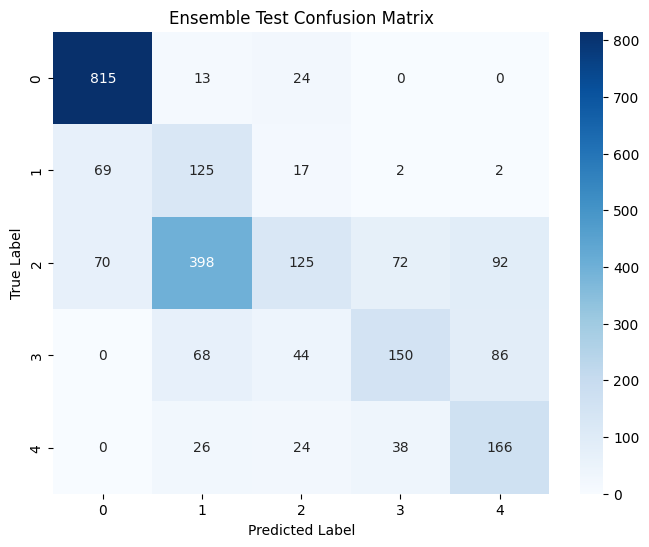

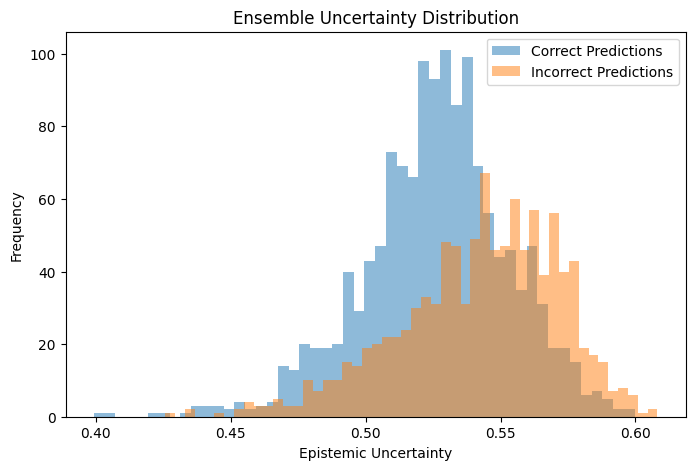

Abstain top 10% uncertainty -> Coverage: 0.900, Accuracy: 0.6047, Macro-F1: 0.5203
Abstain top 5% uncertainty -> Coverage: 0.950, Accuracy: 0.5881, Macro-F1: 0.5101


In [8]:
import glob


def load_fold_models(checkpoint_paths, device):
    model_entries = []
    for ckpt_path in checkpoint_paths:
        if not os.path.exists(ckpt_path):
            print(f'Skipping missing checkpoint: {ckpt_path}')
            continue

        m = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=False).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()

        fold_weight = 1.0
        if 'fold_results' in globals():
            try:
                matched = [fr for fr in fold_results if fr.get('top1_ckpt', '') == ckpt_path]
                if len(matched) > 0:
                    fold_weight = float(max(matched[0].get('macro_f1', 1e-6), 1e-6))
            except Exception:
                pass

        model_entries.append({
            'path': ckpt_path,
            'model': m,
            'weight': fold_weight,
            'temperature': 1.0,
        })
    return model_entries


def estimate_temperature_grid(model, dataloader_val, temp_grid=None):
    if temp_grid is None:
        temp_grid = [0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

    if dataloader_val is None:
        return 1.0

    model.eval()
    logits_all = []
    labels_all = []
    with torch.no_grad():
        for inputs, labels in dataloader_val:
            inputs = inputs.to(device)
            labels = labels.to(device)
            logits = model(inputs)
            logits_all.append(logits)
            labels_all.append(labels)

    if len(logits_all) == 0:
        return 1.0

    logits_all = torch.cat(logits_all, dim=0)
    labels_all = torch.cat(labels_all, dim=0)

    best_temp = 1.0
    best_ce = float('inf')

    for t in temp_grid:
        scaled_logits = logits_all / t
        ce = F.cross_entropy(scaled_logits, labels_all).item()
        if ce < best_ce:
            best_ce = ce
            best_temp = t

    return float(best_temp)


def evaluate_ensemble(model_entries, dataloader):
    all_preds, all_labels, all_uncertainties = [], [], []

    weights = np.array([max(me['weight'], 1e-8) for me in model_entries], dtype=np.float32)
    weights = weights / weights.sum()

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Ensemble Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            alpha_weighted_sum = None
            for me, w in zip(model_entries, weights):
                logits = me['model'](inputs)
                scaled_logits = logits / me['temperature']
                alpha = softplus_evidence(scaled_logits) + 1
                alpha_weighted_sum = alpha * w if alpha_weighted_sum is None else alpha_weighted_sum + (alpha * w)

            S = torch.sum(alpha_weighted_sum, dim=1, keepdim=True)
            uncertainty = NUM_CLASSES / S
            _, preds = torch.max(alpha_weighted_sum, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(uncertainty.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)


# Keep off by default to preserve flow order.
USE_ENSEMBLE = True

if USE_ENSEMBLE:
    candidate_ckpts = sorted(glob.glob('best_fold_*_top1.pth'))
    if len(candidate_ckpts) == 0:
        candidate_ckpts = sorted(glob.glob('best_fold_*.pth'))

    if len(candidate_ckpts) == 0:
        print('No fold checkpoints found. Run Cell 7 first.')
    else:
        print(f'Found fold checkpoints: {candidate_ckpts}')
        model_entries = load_fold_models(candidate_ckpts, device)

        if len(model_entries) == 0:
            print('No valid checkpoints could be loaded.')
        elif 'test' not in dataloaders:
            print('Test dataloader not found.')
        else:
            if 'val' in dataloaders:
                print('Calibrating per-fold temperature on validation set...')
                for me in model_entries:
                    me['temperature'] = estimate_temperature_grid(me['model'], dataloaders['val'])
                    print(
                        f"{os.path.basename(me['path'])}: "
                        f"weight={me['weight']:.4f}, temperature={me['temperature']:.2f}"
                    )
            else:
                print('Validation dataloader missing. Using default temperature=1.0 for all folds.')

            y_true_e, y_pred_e, u_e = evaluate_ensemble(model_entries, dataloaders['test'])

            acc_e = accuracy_score(y_true_e, y_pred_e)
            macro_f1_e = f1_score(y_true_e, y_pred_e, average='macro')
            weighted_f1_e = f1_score(y_true_e, y_pred_e, average='weighted')

            print(f"\nEnsemble Test Accuracy: {acc_e:.4f}")
            print(f"Ensemble Test Macro-F1: {macro_f1_e:.4f}")
            print(f"Ensemble Test Weighted-F1: {weighted_f1_e:.4f}")
            print('\nEnsemble Classification Report:')
            try:
                print(classification_report(y_true_e, y_pred_e, target_names=class_names, digits=4))
            except Exception:
                print(classification_report(y_true_e, y_pred_e, digits=4))

            cm_e = confusion_matrix(y_true_e, y_pred_e)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.title('Ensemble Test Confusion Matrix')
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(u_e[y_true_e == y_pred_e], bins=50, alpha=0.5, label='Correct Predictions')
            plt.hist(u_e[y_true_e != y_pred_e], bins=50, alpha=0.5, label='Incorrect Predictions')
            plt.xlabel('Epistemic Uncertainty')
            plt.ylabel('Frequency')
            plt.legend()
            plt.title('Ensemble Uncertainty Distribution')
            plt.show()

            # Simple abstention analysis: drop highest-uncertainty samples and report retained accuracy
            for q in [0.90, 0.95]:
                thr = np.quantile(u_e, q)
                keep = u_e <= thr
                kept_ratio = np.mean(keep)
                if np.sum(keep) > 0:
                    acc_kept = accuracy_score(y_true_e[keep], y_pred_e[keep])
                    macro_f1_kept = f1_score(y_true_e[keep], y_pred_e[keep], average='macro')
                    print(
                        f"Abstain top {(1.0 - q) * 100:.0f}% uncertainty -> "
                        f"Coverage: {kept_ratio:.3f}, Accuracy: {acc_kept:.4f}, Macro-F1: {macro_f1_kept:.4f}"
                    )
else:
    print('Ensemble is configured. Set USE_ENSEMBLE = True after Cell 7 finishes.')

## 9. Download Checkpoints (Final Step)
Run this after training/evaluation to download `kfold_checkpoints.zip`.

In [9]:
import os
import glob
import zipfile

# Download helper for all fold checkpoints
fold_ckpts = sorted(glob.glob('best_fold_*.pth'))

if len(fold_ckpts) > 0:
    zip_path = 'kfold_checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
        for fp in fold_ckpts:
            zf.write(fp)
    model_path = zip_path
    print(f"Prepared archive with fold checkpoints: {fold_ckpts}")
else:
    model_path = None

if model_path is not None and os.path.exists(model_path):
    try:
        from google.colab import files
        print("Running in Google Colab. Initiating download...")
        files.download(model_path)
    except ImportError:
        from IPython.display import FileLink, display
        print("Not in Colab. Creating a universal download link...")
        display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print("No fold checkpoints found. Run Cell 7 first.")

Prepared archive with fold checkpoints: ['best_fold_1.pth', 'best_fold_1_top1.pth', 'best_fold_1_top2.pth', 'best_fold_2.pth', 'best_fold_2_top1.pth', 'best_fold_2_top2.pth', 'best_fold_3.pth', 'best_fold_3_top1.pth', 'best_fold_3_top2.pth', 'best_fold_4.pth', 'best_fold_4_top1.pth', 'best_fold_4_top2.pth', 'best_fold_5.pth', 'best_fold_5_top1.pth', 'best_fold_5_top2.pth']
Running in Google Colab. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>